In [56]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
np.random.seed(100)
torch.manual_seed(100)


## Question 1

In [58]:
def simulate_narx1(N, sigma=0.01, seed=0):
    "Simule le système NARX1 sur N pas de temps."
    "Le système a :"","
    "- 1 entrée  : u(k)"","
    "- 2 sorties : y1(k), y2(k)"","
    
    "Les équations sont :"","
    "y1(k+1) = 0.5*y2(k-1) + sin(y2(k)) + 0.3*u(k-1) + bruit"","
    "y2(k+1) = 0.5*y1(k-1) + sin(y1(k)) + 0.2*u(k)   + bruit"","
    
 
   
    rng = np.random.default_rng(seed)
    
    t = np.arange(N)
    u = (0.5 * np.sin(2 * np.pi * t / 25) + 0.3 * np.sin(2 * np.pi * t / 10)+ 0.2 * rng.standard_normal(N))
   #Initialisation : toutes les conditions initiales à 0
    y1 = np.zeros(N)
    y2 = np.zeros(N)

    #Bruits
    w1 = sigma * rng.standard_normal(N)
    w2 = sigma * rng.standard_normal(N)
    # Simulation pas à pas
    # On commence à k=2 pour avoir accès à y(k-1)
    for k in range(2, N - 1):
        y1[k + 1] = 0.5 * y2[k - 1] + np.sin(y2[k]) + 0.3 * u[k - 1] + w1[k + 1]
        y2[k + 1] = 0.5 * y1[k - 1] + np.sin(y1[k]) + 0.2 * u[k]     + w2[k + 1]

    U = u.reshape(-1, 1)              
    Y = np.column_stack([y1, y2])      
    
    return U, Y
    
def simulate_narx2(N, sigma=0.01, seed=100):
    "Simule le système NARX2 sur N pas de temps."
    
    "Le système a :"
    "- 2 entrées : u1(k), u2(k)",
    "- 2 sorties : y1(k), y2(k)",
    
    "Les équations sont :",
    "      y1(k+1) = [y1(k)*y1(k-1)*y1(k-2)*(y1(k-2)-1)*u2(k-1) + u2(k)] / [1 + y2(k-1)^2 + y2(k-2)^2]",
    "      y2(k+1) = [y2(k)*y2(k-1)*y2(k-2)*(y2(k-2)-1)*u1(k-1) + u1(k)] / [1 + y1(k-1)^2 + y1(k-2)^2]",
    rng = np.random.default_rng(seed)
    
    t = np.arange(N)
    
    # Entrées : petites amplitudes pour éviter la divergence de NARX2
    u1 = 0.4 * np.sin(2 * np.pi * t / 20) + 0.1 * rng.standard_normal(N)
    u2 = 0.4 * np.cos(2 * np.pi * t / 15) + 0.1 * rng.standard_normal(N)
    
    y1 = np.zeros(N)
    y2 = np.zeros(N)
    
    w1 = sigma * rng.standard_normal(N)
    w2 = sigma * rng.standard_normal(N)
    
    # On démarre à k=3 pour avoir accès à k-2
    for k in range(3, N - 1):
        # Dénominateurs (on ajoute 1 pour éviter la division par zéro)",
        denom1 = 1 + y2[k - 1] ** 2 + y2[k - 2] ** 2
        denom2 = 1 + y1[k - 1] ** 2 + y1[k - 2] ** 2
        num1 = y1[k] * y1[k-1] * y1[k-2] * (y1[k-2] - 1) * u2[k-1] + u2[k]
        num2 = y2[k] * y2[k-1] * y2[k-2] * (y2[k-2] - 1) * u1[k-1] + u1[k]
        y1[k + 1] = num1 / denom1 + w1[k + 1]
        y2[k + 1] = num2 / denom2 + w2[k + 1]
    # Clipping de sécurité pour éviter l'explosion numérique (passage corrigé par Claude après coup)
        y1[k + 1] = np.clip(y1[k + 1], -10, 10)
        y2[k + 1] = np.clip(y2[k + 1], -10, 10)
    
    U = np.column_stack([u1, u2])
    Y = np.column_stack([y1, y2])
    
    return U, Y
    
    
N_train = 1000
N_test  = 300

# NARX1
U1_tr, Y1_tr = simulate_narx1(N_train, sigma=0.02, seed=100)
U1_ts, Y1_ts = simulate_narx1(N_test,  sigma=0.02, seed=200)

# NARX2
U2_tr, Y2_tr = simulate_narx2(N_train, sigma=0.02, seed=100)
U2_ts, Y2_ts = simulate_narx2(N_test,  sigma=0.02, seed=200)

print("Données NARX1 générées :\n")
print("Train : U=", U1_tr.shape, ", Y=", Y1_tr.shape)
print("Test  : U=", U1_ts.shape, ",Y=",Y1_ts.shape)    
print("Données NARX2 générées :\n")
print("Train : U=", U2_tr.shape, ", Y=", Y2_tr.shape)
print("Test  :U=",U2_ts.shape, ", Y= ",Y2_ts.shape)

Données NARX1 générées :

Train : U= (1000, 1) , Y= (1000, 2)
Test  : U= (300, 1) ,Y= (300, 2)
Données NARX2 générées :

Train : U= (1000, 2) , Y= (1000, 2)
Test  :U= (300, 2) , Y=  (300, 2)


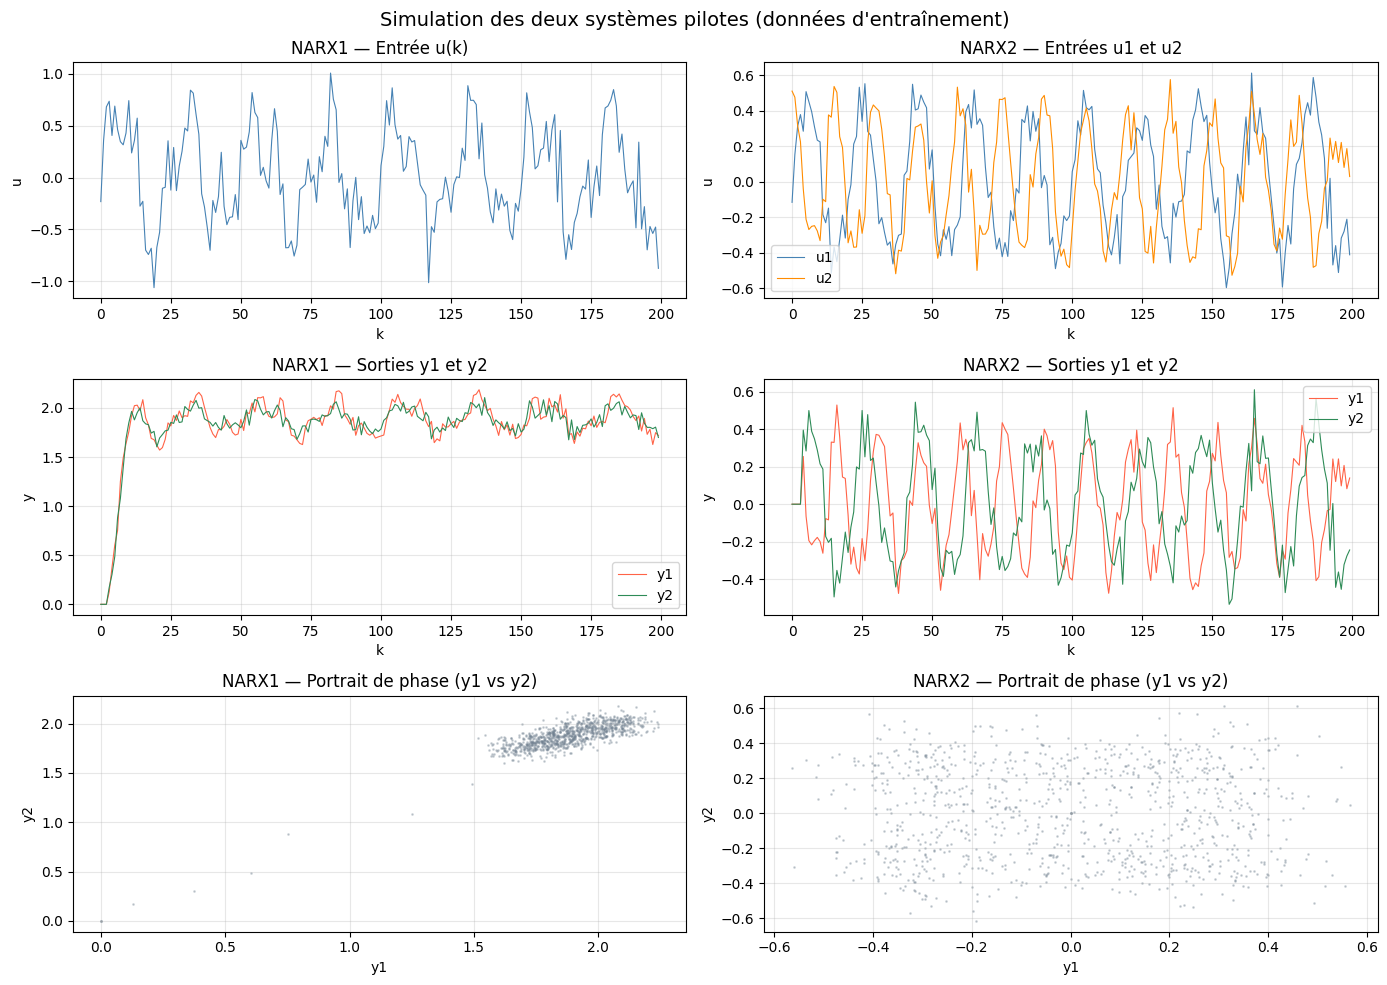

In [59]:
# ——— Visualisation des séries simulées ———

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Simulation des deux systèmes pilotes (données d'entraînement)", fontsize=14)

# NARX1
ax = axes[0, 0]
ax.plot(U1_tr[:200, 0], color='steelblue', linewidth=0.8)
ax.set_title("NARX1 — Entrée u(k)")
ax.set_xlabel("k")
ax.set_ylabel("u")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(Y1_tr[:200, 0], color='tomato', linewidth=0.8, label='y1')
ax.plot(Y1_tr[:200, 1], color='seagreen', linewidth=0.8, label='y2')
ax.set_title("NARX1 — Sorties y1 et y2")
ax.set_xlabel("k")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2, 0]
ax.scatter(Y1_tr[:, 0], Y1_tr[:, 1], s=1, alpha=0.3, color='slategray')
ax.set_title("NARX1 — Portrait de phase (y1 vs y2)")
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.grid(True, alpha=0.3)

# NARX2
ax = axes[0, 1]
ax.plot(U2_tr[:200, 0], color='steelblue', linewidth=0.8, label='u1')
ax.plot(U2_tr[:200, 1], color='darkorange', linewidth=0.8, label='u2')
ax.set_title("NARX2 — Entrées u1 et u2")
ax.set_xlabel("k")
ax.set_ylabel("u")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(Y2_tr[:200, 0], color='tomato', linewidth=0.8, label='y1')
ax.plot(Y2_tr[:200, 1], color='seagreen', linewidth=0.8, label='y2')
ax.set_title("NARX2 — Sorties y1 et y2")
ax.set_xlabel("k")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2, 1]
ax.scatter(Y2_tr[:, 0], Y2_tr[:, 1], s=1, alpha=0.3, color='slategray')
ax.set_title("NARX2 — Portrait de phase (y1 vs y2)")
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Question 2

### Question 2. A.

To find the delay with the historical dataset of input and output, one can use the correlation between the input at time k - t and the output at time k. Then, with the correlation graph, the maximum should be close to the delay. As a matter of fact, as the delay is the amount of periods of time during which an input has no effect on the output, this maximum of correlation should replicate it.

For the input lag, this is impossible to find without the delay. Therefore, one need to have the correlation first, to guess the input lag. Then, input lag can be seen as how many period of inputs are useful. As such, every input at time k - d - t correlated to output at time k are useful. This is equivalent to considering the number of period at which the correlation between input from the delay and output is positive. As soon as it is negative or null, there is no more use of the k + 1 output for the input at time k - d + 1.

For the output lag, one can see it as the size of the memory of the system. As such, if the output at period k is influenced by the previous output up until 4 periods ago, then the output lag is of 4. Therefore, to get the output lag, one need to find at which period t will the autocorrelation between the output at k and the output at k - t be null or negative.

### Question 2. B.

In [ ]:
def predict_narx_multistep(model, scaler, U_test, d, na, nb,
                          Y_init=None, U_init=None):
    """
    Simulation NARX en boucle fermée (multi-step)
    On réutilise les sorties prédites pour construire la suite.
    """

    N_ts = U_test.shape[0]
    nu = U_test.shape[1]

    # taille du contexte (un peu de marge)
    context = max(d + na, nb) + 2

    # init (si rien fourni → zéros)
    Y_buf = np.zeros((context, 2)) if Y_init is None else Y_init.copy()
    U_buf = np.zeros((context, nu)) if U_init is None else U_init.copy()

    # on colle le contexte + test
    U_full = np.vstack((U_buf, U_test))

    Y_full = np.zeros((context + N_ts, 2))
    Y_full[:context] = Y_buf

    Y_hat = np.zeros((N_ts, 2))

    for t in range(N_ts):

        k = context + t - 1
        features = []

        # sorties passées (prédites)
        for j in range(2):
            for lag in range(na + 1):
                idx = k - d - lag
                if idx >= 0:
                    features.append(Y_full[idx, j])
                else:
                    features.append(0.0)

        # entrées passées (réelles)
        for i in range(nu):
            for lag in range(nb + 1):
                idx = k - lag
                if idx >= 0:
                    features.append(U_full[idx, i])
                else:
                    features.append(0.0)

        x = np.array(features).reshape(1, -1)
        x = scaler.transform(x)

        y_pred = model.predict(x)[0]

        # éviter que ça parte en vrille
        y_pred = np.clip(y_pred, -50, 50)

        Y_hat[t] = y_pred
        Y_full[context + t] = y_pred

    return Y_hat

Fonction prête.
